# 03 -  Desarrollo de Modelo Predictivo

## 1. Descripción General

En este notebook se desarrollará la fase de modelado del proyecto de predicción de precios de Airbnb. El objetivo principal de esta etapa es entrenar, evaluar y comparar distintos modelos de Machine Learning capaces de estimar el precio de una propiedad a partir de las variables seleccionadas durante los procesos de *Data Exploration* y *Feature Engineering*.

A diferencia de las etapas anteriores, donde el enfoque estuvo centrado en la comprensión de los datos, la creación de características y la selección de variables, en esta fase se trabajará sobre un dataset final (`df_model`) que ya ha sido preprocesado, transformado y validado. Esto permite concentrar el análisis exclusivamente en el desempeño de los modelos predictivos.

Para este proyecto se utilizarán tres enfoques de modelado:

- ***Linear Regression***: como modelo baseline de referencia debido a su simplicidad e interpretabilidad.
- ***Random Forest Regressor***: un modelo basado en ensambles de árboles capaz de capturar relaciones no lineales entre las variables.
- ***XGBoost Regressor***: uno de los algoritmos más utilizados en problemas de datos tabulares por su capacidad predictiva y robustez.

El proceso de modelado abarca los pasos necesarios para entrenar, evaluar y seleccionar el mejor modelo:

- División de los datos en conjuntos de entrenamiento, validación y prueba.
- Entrenamiento de los modelos candidatos con hiperparámetros iniciales.
- Evaluación de los modelos utilizando métricas de regresión apropiadas para el problema, incluyendo **R²**, **RMSE** y **MAE**.
- Optimización de hiperparámetros y comparación de resultados para seleccionar el modelo con mejor desempeño.
- Evaluación del modelo ganador sobre datos no vistos para analizar su capacidad de generalización, detectar posibles señales de sobreajuste y validar rendimiento.

Al concluir este notebook se contará con un modelo predictivo final, validado y documentado, capaz de estimar precios de propiedades Airbnb y listo para ser utilizado en futuras etapas de inferencia, despliegue y construcción de servicios de predicción.

## 2. Importación de Librerías y Carga del Dataset

In [1]:
# Import libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Train / validation / test split
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Regression metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model persistence
import joblib

# Load the final modeling dataset generated during the Feature Engineering phase.
df_model = pd.read_csv("../data/processed/df_model.csv")

# Preview first rows
df_model.head()

,calculated_host_listings_count_entire_homes_log,calculated_host_listings_count_private_rooms_log,dist_to_nearest_attraction_log,beds_log,amenity_score,accommodates_log,bedrooms_log,bathrooms_log,attractions_within_radius_log,commercial_within_radius,...,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,log_price
0,-0.269577,0.0,1.142523,0.000000,0.143200,-0.652946,-0.563382,-0.573426,-1.147290,-1.206160,...,0,0,0,1,0,0,0,0,0,8.208764
1,0.339627,1.0,-0.314243,3.709511,0.557312,3.126331,2.973722,3.787270,0.737396,0.557533,...,0,1,0,1,1,0,0,0,0,9.798127
2,-0.269577,0.0,-0.360812,0.000000,0.521123,-0.652946,-0.563382,-0.573426,0.476090,-0.306747,...,0,1,1,0,1,0,0,1,0,6.381816
3,0.460845,0.0,0.239169,4.204426,0.673100,3.420238,2.973722,3.491134,-0.335600,-0.840773,...,0,1,0,1,1,1,0,1,0,8.208764
4,-0.730423,1.0,0.652661,0.000000,0.551671,-0.652946,-0.563382,-0.573426,-1.147290,-0.398093,...,0,1,1,0,1,0,0,0,0,5.771441


## 3. División de Datos en Train / Test / Validation

Antes de entrenar los modelos, es necesario dividir el dataset en subconjuntos independientes que permitan desarrollar y evaluar los modelos de forma objetiva.

Para este proyecto se utilizará una estrategia de partición **70% / 15% / 15%**, donde cada conjunto cumple una función específica:

- **Training Set (70%):** utilizado para entrenar los modelos, aprender los patrones presentes en los datos y aplicar validación cruzada.
- **Validation Set (15%):** utilizado para comparar modelos, optimizar hiperparámetros y evaluar su capacidad de generalización durante el desarrollo.
- **Test Set (15%):** reservado exclusivamente para la evaluación final del modelo seleccionado, proporcionando una estimación imparcial de su desempeño sobre datos no vistos.

Esta separación ayudará a prevenir fugas de información (*data leakage*) y permitirá detectar posibles problemas de sobreajuste (*overfitting*) o subajuste (*underfitting*) durante el proceso de modelado.

La variable objetivo utilizada en este proyecto será `log_price`, ya que la transformación logarítmica aplicada durante la etapa de *Feature Engineering* permitió reducir la asimetría de la distribución del precio y mejorar las condiciones para el entrenamiento de modelos de regresión.

============= DATASET SPLITS =============
X_train: (15015, 30)
X_val:   (3217, 30)
X_test:  (3218, 30)

y_train: (15015,)
y_val:   (3217,)
y_test:  (3218,)

============= TARGET DISTRIBUTION =============

              Train   Validation         Test
count  15015.000000  3217.000000  3218.000000
mean       6.975443     6.962141     6.964193
std        0.733728     0.729505     0.731168
min        4.852030     4.844187     4.948760
25%        6.496020     6.486161     6.481577
50%        6.957497     6.941190     6.961296
75%        7.387090     7.377759     7.381346
max       11.812786    11.520010    11.326066


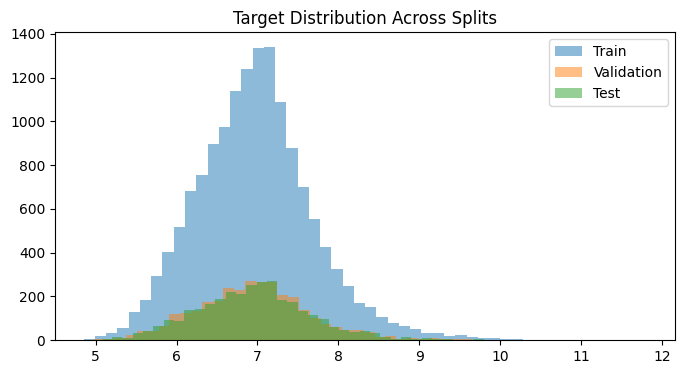

In [2]:
# Import feature list from model configuration
from src.settings.model_config import MODEL_FEATURES

# 1. Define features and target

# Input features
X = df_model[MODEL_FEATURES]

# Target variable
y = df_model["log_price"]

# 2. Train / Validation / Test split

# First split:
# 70% training
# 30% temporary (validation + test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split:
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# 3. Validate dataset shapes
print("============= DATASET SPLITS =============")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")


# 4. Validate target distributions
print("\n============= TARGET DISTRIBUTION =============\n")

# Combine distributions into one table
summary = pd.concat([
    y_train.describe().to_frame(name="Train"),
    y_val.describe().to_frame(name="Validation"),
    y_test.describe().to_frame(name="Test")
], axis=1)

print(summary)

# Visualize distributions
plt.figure(figsize=(8,4))

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Validation")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution Across Splits")

plt.show()

La partición de los datos se realizó exitosamente siguiendo la estrategia definida de **70% entrenamiento, 15% validación y 15% prueba**, obteniendo 15,015 observaciones para entrenamiento, 3,217 para validación y 3,218 para prueba.

Adicionalmente, se verificó la distribución de la variable objetivo (`log_price`) en cada subconjunto. Los estadísticos descriptivos muestran valores muy similares en términos de media, mediana, desviación estándar y percentiles, lo que indica que los tres conjuntos conservan una distribución consistente del precio transformado.

En particular, la media de `log_price` se mantiene cercana a 6.97 en los tres conjuntos, mientras que la desviación estándar permanece alrededor de 0.73. De forma similar, los percentiles 25, 50 y 75 presentan diferencias mínimas entre entrenamiento, validación y prueba.

Estos resultados sugieren que la partición fue adecuada y que no existen diferencias significativas entre los subconjuntos. Como consecuencia, los modelos podrán entrenarse, optimizarse y evaluarse sobre muestras representativas de la misma población, permitiendo una estimación más confiable de su capacidad de generalización.

## 4. Métricas de Evaluación de Estrategia de Validación

Antes de entrenar los modelos, es necesario definir los criterios que se utilizarán para evaluar su desempeño y comparar sus resultados de manera consistente. Dado que el objetivo del proyecto consiste en predecir una variable numérica continua (`log_price`), se utilizarán métricas estándar para problemas de regresión. Cada métrica proporciona una perspectiva diferente sobre la calidad de las predicciones, por lo que se analizarán de forma complementaria.

### Métricas de evaluación

- **R² Score (Coefficient of Determination)**

    El coeficiente de determinación mide la proporción de la variabilidad de la variable objetivo que es explicada por el modelo a partir de las variables predictoras (características).

    Interpretación de los valores de *R²* :

    - **R² = 1.0**: Representa un ajuste perfecto. El modelo explica toda la variabilidad de los datos. Todas las predicciones coinciden exactamente con los valores reales.
    - **R² entre 0.7 y 0.9**: Indica un muy buen ajuste. El modelo es capaz de explicar la gran mayoría de la varianza en los datos, por lo que es altamente confiable para hacer predicciones.
    - **R² = 0** Indica que el modelo no aporta nada. Es equivalente a simplemente predecir el valor promedio de la variable objetivo para todos los casos, sin importar las características.
    - **R² <> 0**  Indica un modelo deficiente. Significa que el modelo es peor que simplemente trazar una línea horizontal en el promedio. A menudo ocurre cuando el modelo está mal configurado o no se ajusta a la naturaleza de los datos.

    Dado que permite evaluar la capacidad explicativa global del modelo, *R²* será la métrica principal para comparar modelos candidatos*

- **RMSE (Root Mean Squared Error)**

    RMSE mide la magnitud promedio de los errores de predicción penalizando con mayor fuerza los errores grandes. Esta métrica es especialmente útil cuando se desea identificar modelos que minimicen errores significativos en las estimaciones de precio.

    Debido a que el modelo se entrena sobre `log_price`, el RMSE será calculado inicialmente en escala logarítmica. Adicionalmente, para facilitar la interpretación de resultados, se convertirá posteriormente a unidades monetarias reales.


- **MAE (Mean Absolute Error)**

    *MAE* representa el error absoluto promedio entre los valores reales y las predicciones del modelo. A diferencia de RMSE, todos los errores reciben la misma penalización, por lo que proporciona una medida más robusta y fácil de interpretar del error típico esperado.

    Al igual que RMSE, esta métrica será reportada tanto en escala logarítmica como en precios reales.

### Estrategia de validación

Para evaluar correctamente la capacidad de generalización de los modelos, se utilizará una estrategia basada en tres conjuntos de datos:

- **Training Set:** entrenamiento de los modelos.
- **Validation Set:** comparación de modelos y optimización de hiperparámetros.
- **Test Set:** evaluación final del modelo seleccionado.

Además, se aplicará ***K-Fold Cross Validation*** (5 folds) durante la evaluación de los modelos candidatos y durante los procesos de optimización de hiperparámetros.

La validación cruzada permitirá medir la estabilidad de los resultados a través de múltiples particiones del conjunto de entrenamiento, reduciendo la dependencia de una única división de los datos y proporcionando una estimación más robusta del desempeño esperado.

Finalmente, el conjunto de prueba permanecerá completamente aislado durante el desarrollo del proyecto y será utilizado únicamente para la evaluación final del modelo ganador.

## 5. Modelo Base: Linear Regression

### Entrenamiento del modelo

El primer modelo evaluado será una **Regresión Lineal**, utilizada como modelo baseline de referencia para el resto del proyecto. La elección de este algoritmo se debe a su simplicidad, interpretabilidad y amplia utilización en problemas de regresión. Aunque su capacidad para modelar relaciones complejas es limitada, proporciona un punto de comparación fundamental para determinar si modelos más avanzados como Random Forest o XGBoost aportan una mejora significativa en el desempeño predictivo.

Además, debido a que la variable objetivo (`log_price`) presenta una distribución más cercana a la normalidad tras la transformación logarítmica aplicada, la Regresión Lineal constituye una primera aproximación razonable al problema.

En esta sección se entrenará el modelo utilizando el conjunto de entrenamiento y posteriormente se generarán predicciones sobre los conjuntos de entrenamiento y validación para evaluar su capacidad de ajuste y generalización.

In [3]:
# BASELINE MODEL: LINEAR REGRESSION

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Generate predictions
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

print("=" * 50)
print("LINEAR REGRESSION TRAINING COMPLETED")
print("=" * 50)

print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")

print("\nPredictions generated successfully.")

LINEAR REGRESSION TRAINING COMPLETED
Training samples: 15,015
Validation samples: 3,217

Predictions generated successfully.


### Evaluación de desempeño

Una vez entrenado el modelo baseline, es necesario evaluar su capacidad predictiva sobre los conjuntos de entrenamiento y validación. Para ello se utilizarán las métricas definidas previamente: **R²**, **RMSE** y **MAE**. Estas métricas permitirán analizar tanto la capacidad explicativa del modelo como la magnitud de sus errores de predicción.

Adicionalmente, debido a que el modelo fue entrenado sobre la variable objetivo transformada (`log_price`), se calcularán métricas complementarias en la escala original de precios. Esto facilitará la interpretación práctica de los resultados al expresar los errores directamente en unidades monetarias.

Finalmente, la comparación entre las métricas de entrenamiento y validación permitirá identificar posibles señales tempranas de sobreajuste o subajuste antes de avanzar hacia modelos más complejos.

In [ ]:
# LINEAR REGRESSION PERFORMANCE EVALUATION

# Training metrics
train_r2 = r2_score(y_train, y_train_pred_lr)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
train_mae = mean_absolute_error(y_train, y_train_pred_lr)

# Validation metrics
val_r2 = r2_score(y_val, y_val_pred_lr)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
val_mae = mean_absolute_error(y_val, y_val_pred_lr)

# Convert predictions back to original price scale
y_val_real = np.expm1(y_val)
y_val_pred_real = np.expm1(y_val_pred_lr)

# Validation metrics on original price scale
val_rmse_real = np.sqrt(mean_squared_error(y_val_real, y_val_pred_real))
val_mae_real = mean_absolute_error(y_val_real, y_val_pred_real)

# Display results
print("=" * 50)
print("LINEAR REGRESSION PERFORMANCE")
print("=" * 50)

print("\nTRAINING SET")
print(f"R²:   {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE:  {train_mae:.4f}")

print("\nVALIDATION SET")
print(f"R²:   {val_r2:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"MAE:  {val_mae:.4f}")

print("\nREAL PRICE METRICS (VALIDATION)")
print(f"RMSE ($): ${val_rmse_real:,.2f}")
print(f"MAE ($):  ${val_mae_real:,.2f}")

LINEAR REGRESSION PERFORMANCE

TRAINING SET
R²:   0.5746
RMSE: 0.4785
MAE:  0.3499

VALIDATION SET
R²:   0.5942
RMSE: 0.4646
MAE:  0.3475

REAL PRICE METRICS (VALIDATION)
RMSE ($): $2,063.83
MAE ($):  $564.07


La Regresión Lineal obtuvo un R² de 0.57 en entrenamiento y 0.59 en validación, lo que indica que el modelo es capaz de explicar aproximadamente el 59% de la variabilidad observada en los precios de las propiedades Airbnb. Un aspecto positivo es que las métricas de entrenamiento y validación son muy similares. La diferencia entre ambos conjuntos es mínima tanto en R² como en RMSE y MAE, lo que sugiere que el modelo no presenta señales evidentes de sobreajuste y mantiene un comportamiento consistente sobre datos no vistos.

En cuanto a las métricas de error en el conjunto de validación, el modelo obtuvo:

- **RMSE** de $2,063.83 MXN
- **MAE** de $564.07 MXN 

El MAE indica que, en promedio, las predicciones difieren aproximadamente $564 MXN del precio real de una propiedad. Esta métrica proporciona una estimación intuitiva del error típico esperado al utilizar el modelo.

Por otro lado, el RMSE es considerablemente mayor que el MAE. El RMSE obtenido en la escala original de precios fue de $2,063.83 MXN. A diferencia del MAE, esta métrica penaliza con mayor intensidad los errores de gran magnitud, por lo que resulta especialmente sensible a observaciones atípicas o propiedades con precios extremos.

La diferencia observada entre RMSE y MAE sugiere que:

- Aunque la mayoría de las predicciones presentan errores moderados, existe un conjunto reducido de propiedades para las cuales el modelo comete errores significativamente mayores. 
- Hay segmentos específicos (como propiedades de lujo, hoteles o zonas preimum) donde la regresión lineal falla sistemáticamente.
- La relación entre algunas variables y el precio podría ser fuertemente no lineal.

Este comportamiento es común en problemas de predicción de precios, donde alojamientos de lujo o propiedades con características poco frecuentes suelen ser más difíciles de modelar mediante relaciones lineales simples.

En conjunto, estos resultados muestran que la Regresión Lineal constituye un baseline sólido y proporciona un punto de referencia útil para evaluar si modelos más avanzados son capaces de capturar relaciones no lineales y mejorar la precisión de las predicciones.

### Interpretación de coeficientes

Una de las principales ventajas de la Regresión Lineal es su interpretabilidad. A diferencia de modelos más complejos, este algoritmo permite analizar directamente la contribución de cada variable a la predicción del precio.

Los coeficientes aprendidos por el modelo representan la dirección y magnitud de la relación entre cada feature y la variable objetivo (`log_price`), manteniendo constantes las demás variables del modelo.

- Un coeficiente positivo indica que valores mayores de la variable tienden a incrementar el precio estimado.
- Un coeficiente negativo indica que valores mayores de la variable tienden a reducir el precio estimado.
- Coeficientes cercanos a cero sugieren una contribución limitada dentro del modelo.

Debido a que las variables fueron transformadas y escaladas durante la etapa de *Feature Engineering*, los coeficientes no deben interpretarse como cambios monetarios directos. Sin embargo, sí permiten identificar qué características ejercen una mayor influencia positiva o negativa sobre las predicciones del modelo.

A continuación se analizan las variables con mayor impacto dentro de la Regresión Lineal entrenada.

In [5]:
# LINEAR REGRESSION COEFFICIENT ANALYSIS

# Create coefficient dataframe
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr_model.coef_
})

# Absolute importance
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by absolute magnitude
coef_df = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

# Top positive coefficients
top_positive = (
    coef_df
    .sort_values(by="coefficient", ascending=False)
    .head(10)
)

# Top negative coefficients
top_negative = (
    coef_df
    .sort_values(by="coefficient", ascending=True)
    .head(10)
)

print("=" * 50)
print("TOP POSITIVE COEFFICIENTS")
print("=" * 50)
print(top_positive[["feature", "coefficient"]])
print()

print("=" * 50)
print("TOP NEGATIVE COEFFICIENTS")
print("=" * 50)
print(top_negative[["feature", "coefficient"]])
print()

print("=" * 50)
print("LARGEST ABSOLUTE COEFFICIENTS")
print("=" * 50)
print(
    coef_df[
        ["feature", "coefficient", "abs_coefficient"]
    ].head(15)
)

TOP POSITIVE COEFFICIENTS
                      feature  coefficient
11       room_type_hotel_room     0.655043
27       has_air_conditioning     0.360426
10  room_type_entire_home/apt     0.257540
5            accommodates_log     0.249943
29                   has_pool     0.168671
22                     has_tv     0.151741
26      has_outdoor_furniture     0.134545
9    commercial_within_radius     0.116923
24           has_free_parking     0.114735
6                bedrooms_log     0.101068

TOP NEGATIVE COEFFICIENTS
                                             feature  coefficient
13                             room_type_shared_room    -0.893231
4                                      amenity_score    -0.122487
14                       neighbourhood_cleansed_freq    -0.080212
2                     dist_to_nearest_attraction_log    -0.065447
15                          property_group_room_freq    -0.061102
3                                           beds_log    -0.049716
1   calculat

El análisis de coeficientes permite identificar las variables que ejercen una mayor influencia sobre las predicciones de la Regresión Lineal.

**1. Coeficientes positivos**

Entre los coeficientes positivos más importantes destacan las variables relacionadas con el tipo de alojamiento y ciertas amenidades. En particular, las propiedades clasificadas como `Hotel Room` y `Entire Home/Apt` presentan una asociación positiva importante con el precio, lo que sugiere que estos tipos de alojamiento tienden a ubicarse en segmentos de mayor valor dentro del mercado analizado.

Asimismo, variables como `accommodates_log`, `has_air_conditioning`, `has_pool`, `has_tv`, `has_free_parking` y `has_outdoor_furniture` muestran contribuciones positivas relevantes. Este comportamiento resulta consistente con la lógica de negocio, ya que propiedades con mayor capacidad de huéspedes y amenidades adicionales suelen justificar precios más elevados.

**2. Coeficientes negativos**

Por otro lado, los coeficientes negativos más importantes corresponden principalmente a `room_type_shared_room`, indicando que los alojamientos compartidos tienden a asociarse con precios significativamente menores en comparación con otras modalidades de hospedaje. De forma similar, `dist_to_nearest_attraction_log` presenta una relación negativa, lo que sugiere que propiedades ubicadas más lejos de los principales puntos de interés tienden a presentar precios inferiores.

También se observa una contribución negativa en variables relacionadas con la frecuencia de ciertas categorías o ubicaciones, como `neighbourhood_cleansed_freq` y `property_group_room_freq`. Esto podría indicar que categorías más comunes dentro del dataset tienden a concentrarse en segmentos de menor precio.

**3. Coeficientes de `amenity_score` y `bathrooms_log`**

Aunque los coeficientes permiten analizar la dirección de la relación entre las variables y el precio, estos no deben interpretarse de forma aislada. Algunas variables del modelo contienen información relacionada o parcialmente redundante, por lo que la Regresión Lineal distribuye la contribución explicativa entre ellas.

Por ejemplo, durante las etapas previas del proyecto, variables como `amenity_score` y `bathrooms_log` mostraron una señal predictiva importante mediante análisis de correlación, información mutua y feature importance. Sin embargo, en el análisis de coeficientes su contribución aparece reducida o incluso cambia de signo debido a la presencia simultánea de variables relacionadas, como amenidades individuales (`has_tv`, `has_pool`, `has_air_conditioning`, etc.) o variables asociadas a la capacidad y características de la propiedad.

Por esta razón, los coeficientes deben interpretarse como una medida de influencia dentro del conjunto completo de variables del modelo y no como una medida absoluta de importancia predictiva.

En términos generales, los coeficientes obtenidos reflejan patrones coherentes con el mercado de alojamiento temporal: propiedades completas, con mayor capacidad, mejor equipadas y ubicadas en zonas con mayor actividad comercial tienden a asociarse con precios más altos, mientras que alojamientos compartidos o más alejados de las principales atracciones presentan precios inferiores.

### Validación cruzada

Aunque las métricas obtenidas sobre el conjunto de validación proporcionan una estimación del desempeño del modelo, estas dependen de una única partición de los datos. Como resultado, los resultados pueden verse influenciados por la forma específica en que se realizó la división entre entrenamiento y validación.

Para obtener una evaluación más robusta y confiable, se aplicará ***K-Fold Cross Validation*** sobre el conjunto de entrenamiento. Esta técnica divide los datos en múltiples particiones (folds), entrenando y evaluando el modelo varias veces sobre diferentes subconjuntos de datos.

El objetivo es estimar la estabilidad y capacidad de generalización del modelo a través de distintas muestras del dataset. Además del desempeño promedio, la variabilidad entre folds permitirá identificar si los resultados obtenidos son consistentes o si dependen excesivamente de una partición específica.

En este proyecto se utilizará una validación cruzada de 5 folds, reportando la media y desviación estándar del coeficiente de determinación (R²).

In [10]:
# K-FOLD CROSS VALIDATION

from sklearn.model_selection import KFold, cross_val_score

# Define cross-validation strategy
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation using R²
cv_scores = cross_val_score(
    estimator=lr_model,
    X=X_train,
    y=y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

# Summary statistics
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

# Display results
print("=" * 50)
print("FOLD CROSS VALIDATION RESULTS")
print("=" * 50)

for fold, score in enumerate(cv_scores, start=1):
    print(f"Fold {fold}: {score:.4f}")

print()
print(f"Mean R²: {cv_mean:.4f}")
print(f"Std R²:  {cv_std:.4f}")

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.5885
Fold 2: 0.5673
Fold 3: 0.5692
Fold 4: 0.5626
Fold 5: 0.5694

Mean R²: 0.5714
Std R²:  0.0089


La validación cruzada de 5 folds produjo valores de R² consistentes entre las diferentes particiones del conjunto de entrenamiento, con resultados comprendidos entre 0.56 y 0.59.

El modelo obtuvo un R² promedio de 0.5714, muy cercano al desempeño observado previamente sobre los conjuntos de entrenamiento y validación. Esta similitud sugiere que las métricas obtenidas durante la evaluación inicial son representativas del comportamiento general del modelo y no dependen de una partición específica de los datos.

Asimismo, la desviación estándar de 0.0089 indica una variabilidad muy reducida entre folds. Esto significa que el desempeño del modelo permanece estable cuando se entrena y evalúa sobre diferentes subconjuntos del dataset.

En conjunto, los resultados de la validación cruzada proporcionan evidencia adicional de que la Regresión Lineal presenta una capacidad de generalización consistente, estableció una línea base estable con capacidad predictiva moderable y no muestra señales de sobreajuste. Sin embargo, el nivel de desempeño alcanzado también sugiere que aún existe margen de mejora para que modelos basados en árboles capturen patrones más complejos y mejoren el desempeño predictivo.

## 6. Modelo: Random Forest Regressor


### Entrenamiento del modelo

El segundo modelo evaluado será un **Random Forest Regressor**, un algoritmo basado en conjuntos de árboles de decisión que combina múltiples modelos individuales para generar una predicción más robusta y precisa.

A diferencia de la Regresión Lineal, Random Forest es capaz de capturar relaciones no lineales e interacciones complejas entre variables sin requerir una especificación explícita de dichas relaciones. Esta característica resulta especialmente útil en problemas de predicción de precios, donde factores como la ubicación, las amenidades y las características del alojamiento pueden influir de manera no lineal sobre el valor final de la propiedad.

Además, los modelos basados en árboles suelen ser menos sensibles a la presencia de correlaciones entre variables y pueden manejar de forma más efectiva combinaciones complejas de características.

En esta sección se entrenará un modelo Random Forest utilizando los mismos conjuntos de entrenamiento y validación empleados en el baseline, permitiendo una comparación directa entre ambos enfoques.

In [11]:
# RANDOM FOREST REGRESSOR

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

print("=" * 50)
print("RANDOM FOREST TRAINING COMPLETED")
print("=" * 50)

print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")

print("\nPredictions generated successfully.")

RANDOM FOREST TRAINING COMPLETED
Training samples: 15,015
Validation samples: 3,217

Predictions generated successfully.


### Evaluación de Desempeño

Una vez entrenado el modelo Random Forest, se evalúa su capacidad predictiva utilizando las mismas métricas empleadas en el modelo baseline. Esto permite realizar una comparación directa y consistente entre ambos enfoques. Al igual que en la Regresión Lineal, se analizarán las métricas de entrenamiento y validación para evaluar tanto el desempeño predictivo como la capacidad de generalización del modelo.

Además, se calcularán métricas complementarias en la escala original de precios con el fin de facilitar la interpretación práctica de los errores de predicción.

Dado que Random Forest posee una capacidad significativamente mayor para modelar relaciones complejas, también será importante comparar el desempeño entre entrenamiento y validación para identificar posibles señales de sobreajuste.

In [ ]:
# RANDOM FOREST PERFORMANCE EVALUATION

# Training metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)

# Validation metrics
val_r2_rf = r2_score(y_val, y_val_pred_rf)
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

# Convert predictions back to original price scale
y_val_real_rf = np.expm1(y_val)
y_val_pred_real_rf = np.expm1(y_val_pred_rf)

# Validation metrics on original price scale
val_rmse_real_rf = np.sqrt(mean_squared_error(y_val_real_rf, y_val_pred_real_rf))
val_mae_real_rf = mean_absolute_error(y_val_real_rf,y_val_pred_real_rf)

# Display results
print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print("\nTRAINING SET")
print(f"R²:   {train_r2_rf:.4f}")
print(f"RMSE: {train_rmse_rf:.4f}")
print(f"MAE:  {train_mae_rf:.4f}")

print("\nVALIDATION SET")
print(f"R²:   {val_r2_rf:.4f}")
print(f"RMSE: {val_rmse_rf:.4f}")
print(f"MAE:  {val_mae_rf:.4f}")

print("\nREAL PRICE METRICS (VALIDATION)")
print(f"RMSE ($): ${val_rmse_real_rf:,.2f}")
print(f"MAE ($):  ${val_mae_real_rf:,.2f}")

RANDOM FOREST PERFORMANCE

TRAINING SET
R²:   0.9614
RMSE: 0.1441
MAE:  0.0979

VALIDATION SET
R²:   0.7624
RMSE: 0.3555
MAE:  0.2516

REAL PRICE METRICS (VALIDATION)
RMSE ($): $1,218.14
MAE ($):  $400.68


El modelo Random Forest obtuvo un R² de 0.96 sobre el conjunto de entrenamiento y 0.76 sobre el conjunto de validación, superando significativamente el desempeño alcanzado por la Regresión Lineal.

Esta mejora indica que el modelo es capaz de capturar relaciones no lineales e interacciones complejas entre variables que no pueden ser representadas adecuadamente mediante un enfoque lineal. Como resultado, la capacidad explicativa del modelo aumentó considerablemente, pasando de aproximadamente un 59% de la variabilidad explicada en el baseline a más de un 76% sobre datos no vistos.

En cuanto a las métricas de error, el modelo alcanzó un RMSE de 0.3555 y un MAE de 0.2516 sobre el conjunto de validación, mejorando ambas métricas respecto a la Regresión Lineal. Al convertir las predicciones nuevamente a la escala original de precios, se obtuvo un RMSE de $1,218.14 MXN y un MAE de $400.68 MXN. Esto representa una reducción importante del error respecto al modelo baseline (41% de reducción en RMSE y 29% en MAE). 

El hecho de que el RMSE haya mejorado más que el MAE sugiere que Random Forest está manejando mucho mejor los alojamientos Airbnb difíciles o atípicos que estaban generando errores grandes en la Regresión Lineal. También podemos afirmar que las relaciones entre las características de una propiedad Airbnb y su precio no son puramente lineales.

La diferencia observada entre entrenamiento y validación indica cierto grado de sobreajuste, comportamiento habitual en modelos basados en árboles debido a su elevada capacidad de aprendizaje. Sin embargo, el desempeño sobre validación continúa siendo significativamente superior al baseline, por lo que el modelo mantiene una buena capacidad de generalización.

### Feature Importance

A diferencia de la Regresión Lineal, los modelos basados en árboles no generan coeficientes que permitan interpretar directamente la influencia de cada variable sobre la predicción. En su lugar, Random Forest proporciona una medida de **Feature Importance**, que estima cuánto contribuye cada variable a reducir el error durante el proceso de construcción de los árboles.

Esta métrica permite identificar cuáles son las características más relevantes para explicar el precio de una propiedad dentro del modelo. Es importante destacar que la importancia de variables no indica si una característica aumenta o disminuye el precio, sino únicamente cuánto contribuye al poder predictivo del modelo.

El análisis de importancia resulta especialmente útil para validar las conclusiones obtenidas durante la etapa de selección de variables y para comprender qué factores tienen mayor influencia en las decisiones del modelo.

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,accommodates_log,0.168154
1,bathrooms_log,0.157534
2,room_type_entire_home/apt,0.090292
3,property_group_room_freq,0.067572
4,amenity_score,0.066929
5,dist_to_nearest_attraction_log,0.064096
6,commercial_within_radius,0.060494
7,bedrooms_log,0.050355
8,attractions_within_radius_log,0.039954
9,review_scores_mean_segment_ordinal,0.035312


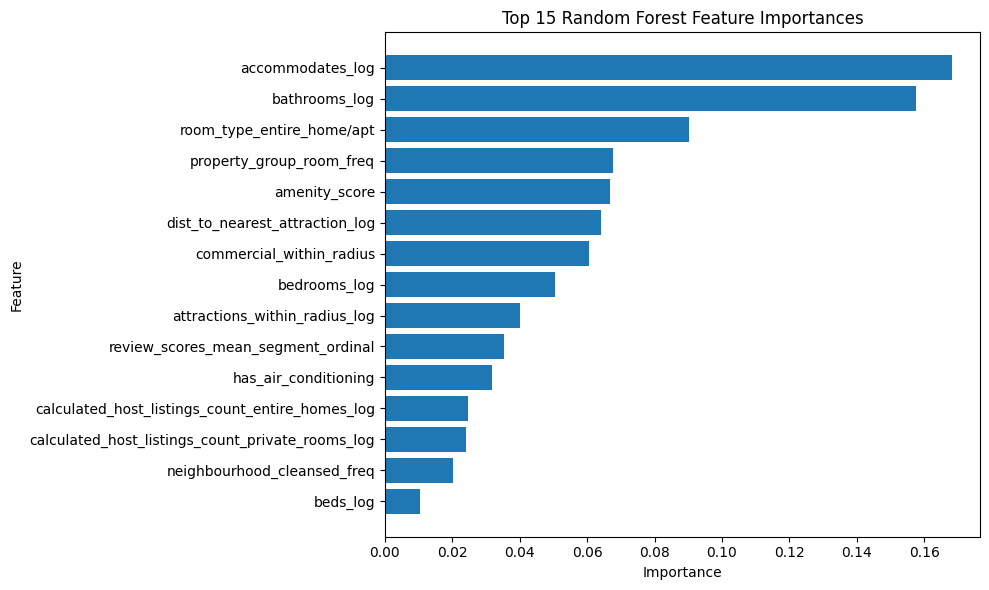

In [13]:
# RANDOM FOREST FEATURE IMPORTANCE

# Create importance dataframe
rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

# Sort descending
rf_importance_df = rf_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Display results
print("=" * 50)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)

display(rf_importance_df)

# Top 15 features
top_features_rf = rf_importance_df.head(15)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features_rf["feature"][::-1],
    top_features_rf["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

El análisis de Feature Importance revela que las características más influyentes para la predicción del precio están relacionadas principalmente con la capacidad del alojamiento, el tamaño de la propiedad, el tipo de alojamiento, las amenidades y la ubicación.

**1. Variables de capacidad**

Las variables más importantes fueron `accommodates_log` y `bathrooms_log`, indicando que la capacidad de huéspedes y el número de baños constituyen algunos de los factores más relevantes para explicar las diferencias de precio entre propiedades. Este resultado es consistente con la lógica de negocio, ya que propiedades más amplias y con mayor capacidad suelen pertenecer a segmentos de mayor valor.

**2. Vairables del tipo de alojamiento**   

También destacan variables relacionadas con la categoría del alojamiento, como `room_type_entire_home/apt` y `property_group_room_freq`, lo que sugiere que el tipo de propiedad desempeña un papel importante en la formación del precio.

**3. Variables de ubicación**  

Las variables de ubicación continúan mostrando una contribución significativa. Factores como `dist_to_nearest_attraction_log`, `commercial_within_radius`, `attractions_within_radius_log` y `neighbourhood_cleansed_freq` aparecen entre las variables más relevantes, confirmando que la localización de la propiedad es uno de los principales determinantes del precio.

**4. Variable `amenity_score`**  

Asimismo, `amenity_score` mantiene una importancia elevada dentro del modelo, validando la utilidad de la variable creada durante la etapa de Feature Engineering. Esto indica que la calidad y cantidad de amenidades disponibles continúa aportando información predictiva relevante incluso después de incorporar múltiples características adicionales.


**5. Variables binarias**
Por otro lado, algunas variables binarias individuales como `has_tv`, `has_pool`, `has_coffee_maker` o `has_elevator` presentan importancias relativamente bajas. Esto sugiere que gran parte de la información asociada a las amenidades ya se encuentra capturada por variables más generales como `amenity_score`.

En conjunto, los resultados muestran que el modelo basa principalmente sus predicciones en factores estructurales de la propiedad (capacidad, tamaño y tipo), complementados por variables de ubicación y calidad de amenidades.